## Import Library

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
     
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=Warning)

## 1. Data Loading and Preview

In [2]:
sample_df = pd.read_csv('../data/sample_submission.csv')
print(sample_df.shape)
sample_df[:2]

(93800, 2)


,id,Depression
0,140700,0
1,140701,0


In [3]:
test_df = pd.read_csv('../data/test.csv')
print(test_df.shape)
test_df[:2]
# (93800, 19)

(93800, 19)


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness
0,140700,Shivam,Male,53.0,Visakhapatnam,Working Professional,Judge,NaN,2.0,NaN,NaN,5.0,Less than 5 hours,Moderate,LLB,No,9.0,3.0,Yes
1,140701,Sanya,Female,58.0,Kolkata,Working Professional,Educational Consultant,NaN,2.0,NaN,NaN,4.0,Less than 5 hours,Moderate,B.Ed,No,6.0,4.0,No


In [4]:
train_df = pd.read_csv('../data/train.csv')
print(train_df.shape)
train_df[:2]
# (140700, 20)

(140700, 20)


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,NaN,4.0,NaN,NaN,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1


## 2. Data Understanding

In [5]:
# numerical and categorical data with NaN values
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     27897 non-null   

In [6]:
train_df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,140700.000000,140700.000000,27897.000000,112782.000000,27898.000000,27897.000000,112790.000000,140700.000000,140696.000000,140700.000000
mean,70349.500000,40.388621,3.142273,2.998998,7.658636,2.944940,2.974404,6.252679,2.988983,0.181713
std,40616.735775,12.384099,1.380457,1.405771,1.464466,1.360197,1.416078,3.853615,1.413633,0.385609
min,0.000000,18.000000,1.000000,1.000000,5.030000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,35174.750000,29.000000,2.000000,2.000000,6.290000,2.000000,2.000000,3.000000,2.000000,0.000000
50%,70349.500000,42.000000,3.000000,3.000000,7.770000,3.000000,3.000000,6.000000,3.000000,0.000000
75%,105524.250000,51.000000,4.000000,4.000000,8.920000,4.000000,4.000000,10.000000,4.000000,0.000000
max,140699.000000,60.000000,5.000000,5.000000,10.000000,5.000000,5.000000,12.000000,5.000000,1.000000


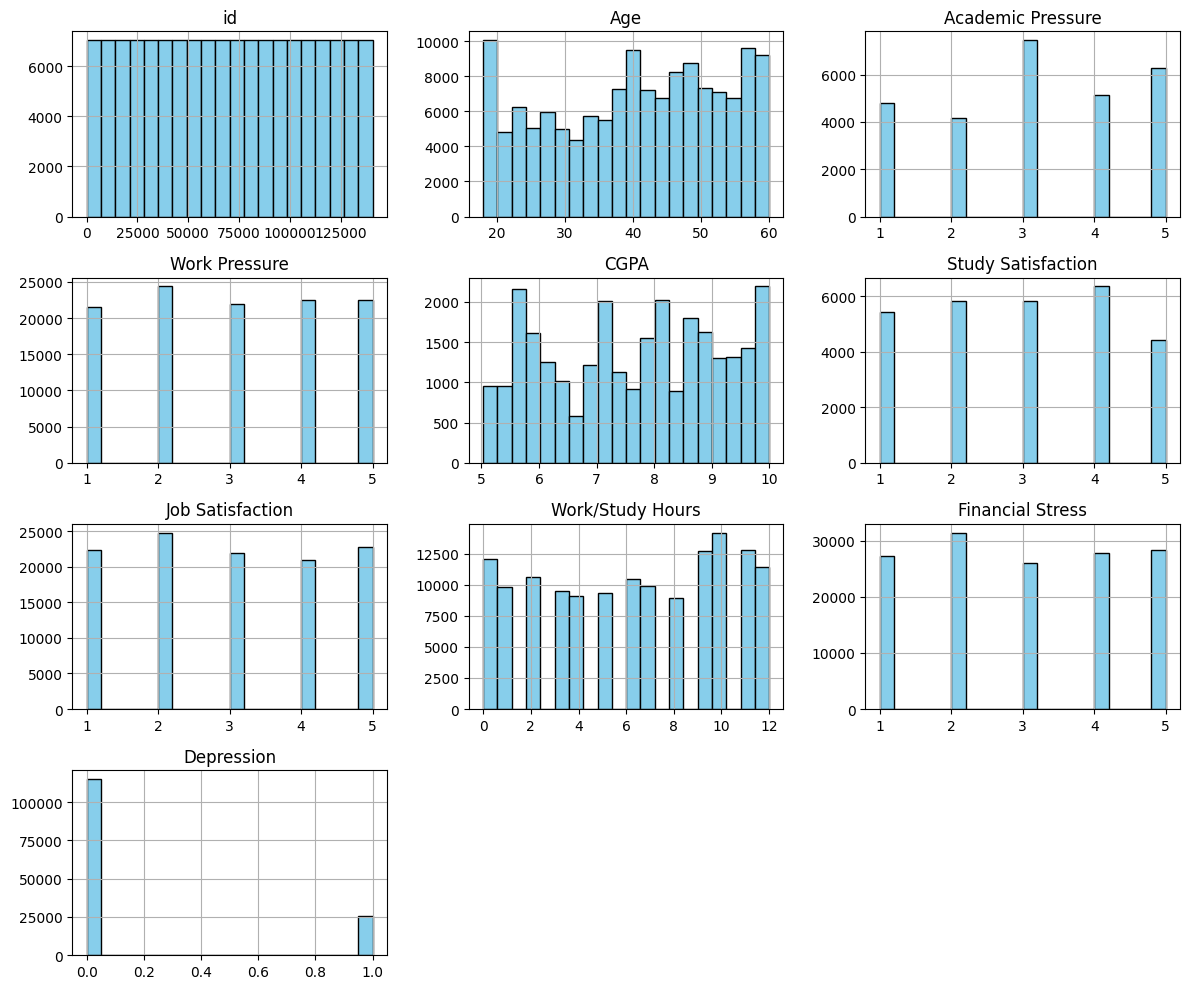

In [7]:
# Plot histograms for all columns
train_df.hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')

# Show the plot
plt.tight_layout()
plt.show()

### **Interpretasi dari Histogram pada Plot**

### **1. `id`**
- Distribusi data terlihat merata, seperti yang diharapkan karena `id` biasanya merepresentasikan identitas unik tanpa pola atau tren tertentu.

### **2. `Age (Usia)`**
- Distribusi data usia cukup seimbang tetapi cenderung lebih banyak pengguna di rentang usia 40–60 tahun. 
- Pengguna dengan usia lebih muda (20–30 tahun) lebih sedikit dibandingkan dengan kelompok usia lainnya.

### **3. `Academic Pressure (Tekanan Akademik)`**
- Nilai tekanan akademik terdistribusi merata pada setiap tingkat, yang menunjukkan tidak ada kecenderungan dominan pada tekanan akademik rendah atau tinggi.

### **4. `CGPA`**
- Distribusi memiliki beberapa puncak (multimodal), menunjukkan bahwa beberapa rentang nilai CGPA, seperti 7–8 dan 9–10, lebih umum.
- Nilai CGPA yang lebih rendah lebih jarang ditemukan.

### **5. `Study Satisfaction (Kepuasan Belajar)`**
- Distribusi cukup merata di semua tingkat, tetapi ada sedikit penurunan pada tingkat kepuasan belajar menengah (level 3).

### **6. `Work Pressure (Tekanan Kerja)`**
- Data terdistribusi secara merata di semua level tekanan kerja, yang menunjukkan tidak ada tingkat tekanan kerja tertentu yang mendominasi dalam populasi.

### **7. `Job Satisfaction (Kepuasan Kerja)`**
- Sama seperti tekanan kerja, tingkat kepuasan kerja juga terdistribusi merata, menunjukkan keberagaman dalam persepsi pengguna terhadap pekerjaan mereka.

### **8. `Work/Study Hours (Jam Kerja/Belajar)`**
- Ada puncak yang signifikan pada rentang 10–12 jam, menunjukkan banyak pengguna bekerja atau belajar dalam rentang waktu tersebut setiap hari.
- Jam kerja/belajar yang sangat rendah atau sangat tinggi lebih jarang ditemukan.

### **9. `Financial Stress (Stres Keuangan)`**
- Tingkat stres keuangan terdistribusi merata di semua level, menunjukkan bahwa pengguna tersebar di seluruh tingkat stres keuangan tanpa ada dominasi tertentu.

### **10. `Depression (Depresi)`**
- Variabel target (`Depression`) menunjukkan ketidakseimbangan kelas yang kuat:
  - Sebagian besar pengguna diklasifikasikan sebagai "tidak depresi" (label `0`).
  - Hanya sebagian kecil pengguna yang diklasifikasikan sebagai "depresi" (label `1`).

---

### **Catatan Penting**
1. **Ketidakseimbangan Kelas pada Depresi**:
   - Hal ini perlu diperhatikan dalam pemrosesan data selanjutnya karena model dapat cenderung bias terhadap kelas mayoritas ("tidak depresi"). Solusi seperti oversampling, undersampling, atau metode lain seperti SMOTE mungkin diperlukan.

## 3. Exploratory Data Analysis (EDA)

### 3.1 Target, Depression Ratio

In [8]:
# Function that return column class, count, and ratio
def class_count_ratio(df, column): 
    value_counts = df[column].value_counts() 
    CCR_df = value_counts.to_frame(name='count')
    CCR_df['ratio'] = CCR_df['count'] / CCR_df['count'].sum()
    CCR_df = CCR_df.reset_index()
    return CCR_df

In [9]:
# Target, Depression class, count and ratio
class_count_ratio(train_df, 'Depression')

,Depression,count,ratio
0,0,115133,0.818287
1,1,25567,0.181713


#### **1. Distribusi Kelas**
- **Kelas 0 (Tidak Depresi)**:
  - Jumlah pengguna: **115,153**.
  - Proporsi: **81.82%** dari total data.
  
- **Kelas 1 (Depresi)**:
  - Jumlah pengguna: **25,567**.
  - Proporsi: **18.17%** dari total data.

#### **2. Ketidakseimbangan Kelas**
- Terdapat ketidakseimbangan yang signifikan dalam distribusi kelas:
  - Kelas **0 (Tidak Depresi)** memiliki jumlah data sekitar **4 kali lebih banyak** dibandingkan kelas **1 (Depresi)**.
  
#### **3. Dampak pada Pemodelan**
- **Ketidakseimbangan data** seperti ini dapat menyebabkan model pembelajaran mesin bias terhadap kelas mayoritas (Kelas 0).
- Model mungkin cenderung memprediksi "Tidak Depresi" lebih sering karena mayoritas data berasal dari kelas tersebut.

### 3.2 Depression Ratio by Gender

In [10]:
# Depression_by_Object_analysis Function
def depression_by_object_analysis(df, object_column, depression_column):
    object_counts = df[object_column].value_counts()
    analysis_df = object_counts.to_frame(name='count')
    analysis_df['depression_count'] = df.groupby(object_column)[depression_column].sum()
    analysis_df['depression_ratio'] = analysis_df['depression_count'] / analysis_df['count']
    analysis_df = analysis_df.reset_index()
    return analysis_df

In [11]:
# Depression_by_Gender
depression_by_object_analysis(train_df, 'Gender', 'Depression')

,Gender,count,depression_count,depression_ratio
0,Male,77464,14296,0.184550
1,Female,63236,11271,0.178237


Men have slightly higher depression_ratio than women.

### 3.3 Depression Count by Age 

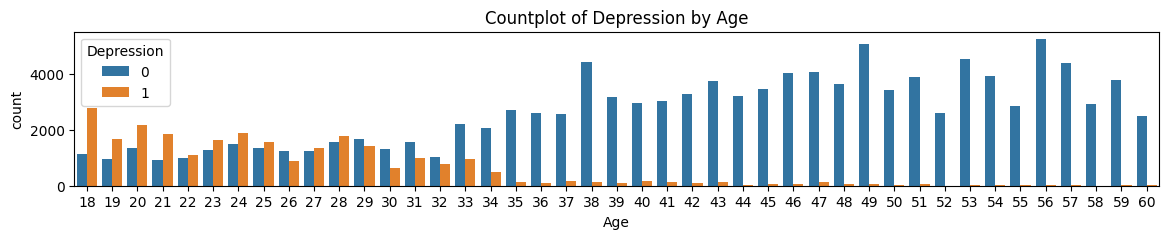

In [12]:
# Countplot of Depression by Age
train_df['Age'] = train_df['Age'].astype(int)
plt.figure(figsize=(14, 2))
sns.countplot(x="Age", hue='Depression', data=train_df)
plt.title("Countplot of Depression by Age")
plt.show()

Dari persebaran data diatas dapat dilihat bahwa semakin muda maka semakin tinggi tingkat depresinya.

### 3.4 Depression Ratio by City

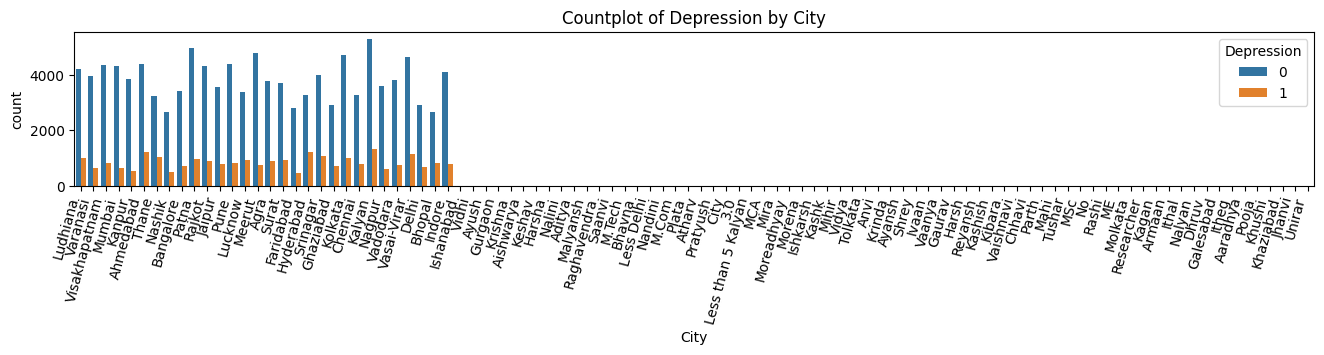

In [13]:
plt.figure(figsize=(16, 2))
sns.countplot(x="City", hue='Depression', data=train_df)
plt.title("Countplot of Depression by City")
plt.xticks(rotation=75, ha='right')
plt.show()

In [14]:
# select City with enough Depression data
depression_by_city = depression_by_object_analysis(train_df, 'City', 'Depression')
depression_by_city_filt  = depression_by_city[depression_by_city['count'] >= 6]
print(depression_by_city_filt.shape)
depression_by_city_filt[:1]

(31, 4)


,City,count,depression_count,depression_ratio
0,Kalyan,6591,1316,0.199666


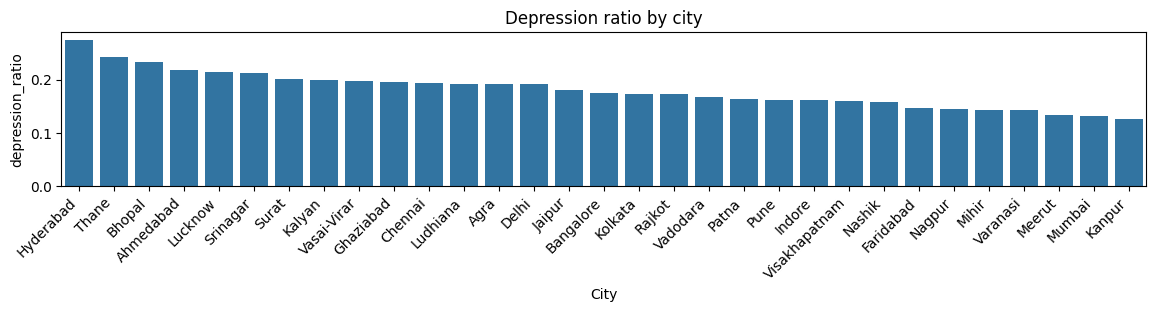

In [15]:
# Depression Ratio by City
depression_by_city_filt = depression_by_city_filt.sort_values(by='depression_ratio', ascending=False)

plt.figure(figsize=(14, 2))
sns.barplot(x="City", y="depression_ratio",data=depression_by_city_filt)
plt.title("Depression ratio by city")
plt.xticks(rotation=45, ha='right')
plt.show()

### 3.5 Depression Ratio by Working Professional or Student

In [16]:
depression_by_object_analysis(train_df, 'Working Professional or Student', 'Depression')

,Working Professional or Student,count,depression_count,depression_ratio
0,Working Professional,112799,9231,0.081836
1,Student,27901,16336,0.585499


### 3.6 Depression by Profession

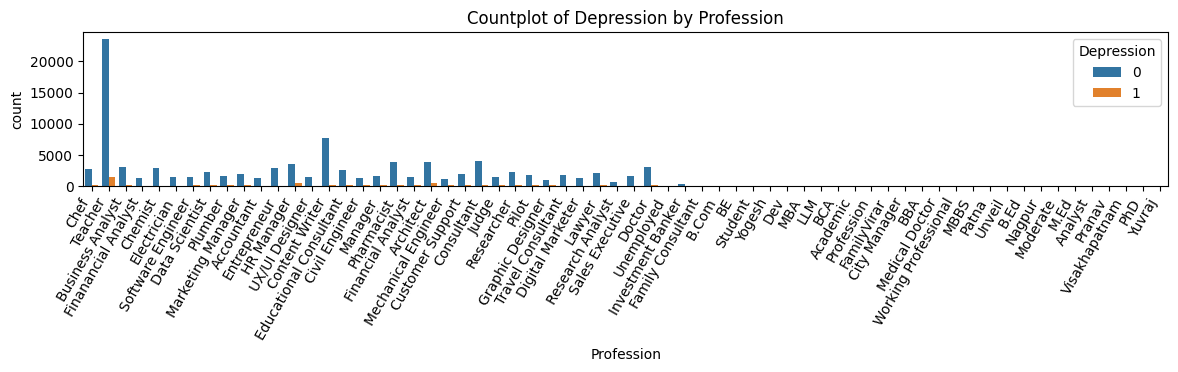

In [17]:
plt.figure(figsize=(14, 2))
sns.countplot(x="Profession", hue='Depression', data=train_df)
plt.title("Countplot of Depression by Profession")
plt.xticks(rotation=60, ha='right')
plt.show()

In [18]:
# select Profession with enough Depression data
profession_by_depression = depression_by_object_analysis(train_df, 'Profession', 'Depression')
profession_by_depression_filt  = profession_by_depression[profession_by_depression['count'] >= 10]
print(profession_by_depression_filt.shape)
profession_by_depression_filt[:5]

(35, 4)


,Profession,count,depression_count,depression_ratio
0,Teacher,24906,1386,0.055649
1,Content Writer,7814,146,0.018684
2,Architect,4370,433,0.099085
3,Consultant,4229,199,0.047056
4,HR Manager,4022,430,0.106912


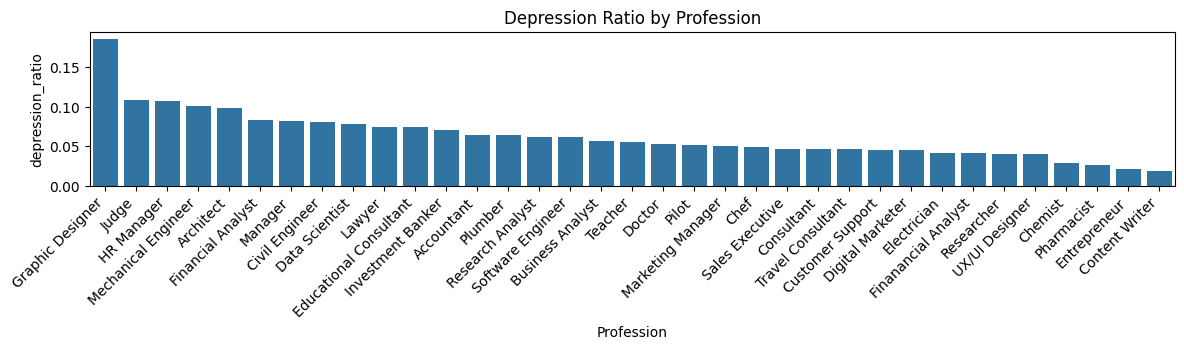

In [19]:
# Depression Ratio by Profession
profession_by_depression_filt = profession_by_depression_filt.sort_values(by='depression_ratio', 
                                                        ascending=False)

plt.figure(figsize=(14, 2))
sns.barplot(x="Profession", y="depression_ratio",data=profession_by_depression_filt)
plt.title("Depression Ratio by Profession")
plt.xticks(rotation=45, ha='right')
plt.show()
# Graphic Designer, Judge - Chemist, Pharmacist, Entrepreneur, Content Writer

### 3.7 Depression by Academic & Work Pressure

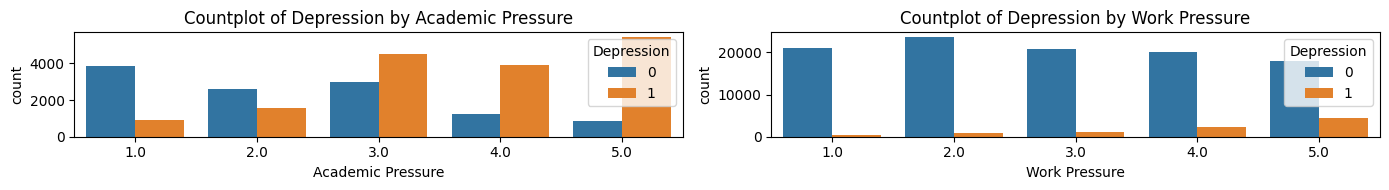

In [20]:
# Countplot of Depression by Academic & Work Pressure
plt.figure(figsize=(14,2))  
plt.subplot(1, 2, 1) 
sns.countplot(x="Academic Pressure", hue='Depression', data=train_df)
plt.title("Countplot of Depression by Academic Pressure")

plt.subplot(1, 2, 2)  
sns.countplot(x="Work Pressure", hue='Depression', data=train_df)
plt.title("Countplot of Depression by Work Pressure")

plt.tight_layout() 
plt.show()

### 3.8 Depression by CGPA (Cumulative Grade Point Average)

In [21]:
# CGPA
class_count_ratio(train_df, 'CGPA')

,CGPA,count,ratio
0,8.0400,822,0.029464
1,9.9600,425,0.015234
2,5.7400,410,0.014696
3,8.9500,371,0.013298
4,9.2100,343,0.012295
...,...,...,...
326,6.6400,1,0.000036
327,7.0625,1,0.000036
328,6.9800,1,0.000036
329,6.4400,1,0.000036


In [22]:
# CGPA grouping 
CGPA_df = pd.DataFrame()
CGPA_df['CGPA'] = train_df.CGPA
CGPA_df['Depression'] = train_df.Depression
CGPA_df = CGPA_df.dropna(axis=0).reset_index(drop=True)
CGPA_df['CGPA_group'] = pd.qcut(CGPA_df['CGPA'], q=10, 
                                labels=['Q1','Q2','Q3','Q4','Q5','Q6','Q7','Q8','Q9','Q10'])
print(CGPA_df.shape)
CGPA_df.head()

(27898, 3)


,CGPA,Depression,CGPA_group
0,8.97,1,Q8
1,5.90,0,Q2
2,7.03,0,Q4
3,5.59,1,Q1
4,8.13,0,Q6


In [23]:
# depression_by_CGPA_group
depression_by_CGPA_group = depression_by_object_analysis(CGPA_df, 'CGPA_group', 'Depression')
depression_by_CGPA_group.sort_values(by='CGPA_group', ascending=True)

,CGPA_group,count,depression_count,depression_ratio
2,Q1,2848,1595,0.560042
3,Q2,2823,1568,0.555437
4,Q3,2808,1674,0.596154
8,Q4,2702,1556,0.575870
1,Q5,2875,1588,0.552348
0,Q6,2877,1752,0.608968
9,Q7,2633,1684,0.639575
5,Q8,2800,1745,0.623214
6,Q9,2776,1603,0.577450
7,Q10,2756,1571,0.570029


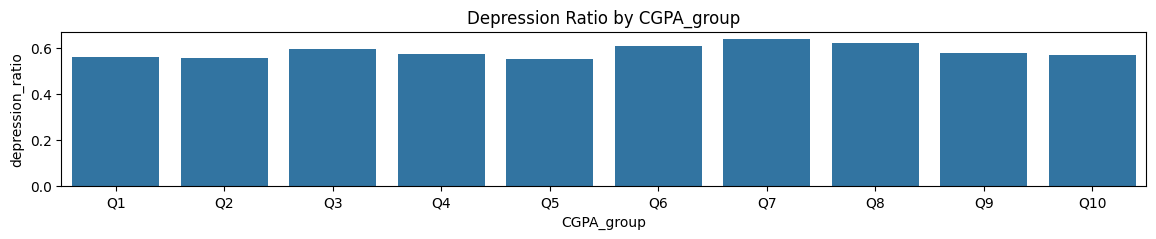

In [24]:
# Depression Ratio by CGPA_group
depression_by_CGPA_group = depression_by_CGPA_group.sort_values(by='CGPA_group', ascending=True)

plt.figure(figsize=(14, 2))
sns.barplot(x="CGPA_group", y="depression_ratio",data=depression_by_CGPA_group)
plt.title("Depression Ratio by CGPA_group")
plt.show()
# Students in the upper and middle CGPA (Q7, 8, 6) tend to be more depressed.

### 3.9 Depression by Study & Job Satisfaction

In [25]:
# depression by study satisfaction
depression_by_study = depression_by_object_analysis(train_df, 'Study Satisfaction', 'Depression')
depression_by_study.sort_values(by='Study Satisfaction', ascending=False)

,Study Satisfaction,count,depression_count,depression_ratio
4,5.0,4423,2089,0.472304
0,4.0,6360,3265,0.513365
2,3.0,5823,3354,0.575992
1,2.0,5840,3769,0.645377
3,1.0,5451,3857,0.707577


In [26]:
# depression by job satisfaction
depression_by_job = depression_by_object_analysis(train_df, 'Job Satisfaction', 'Depression')
depression_by_job.sort_values(by='Job Satisfaction', ascending=False)

,Job Satisfaction,count,depression_count,depression_ratio
1,5.0,22812,884,0.038752
4,4.0,20920,825,0.039436
3,3.0,21951,1196,0.054485
0,2.0,24783,2437,0.098334
2,1.0,22324,3885,0.174028


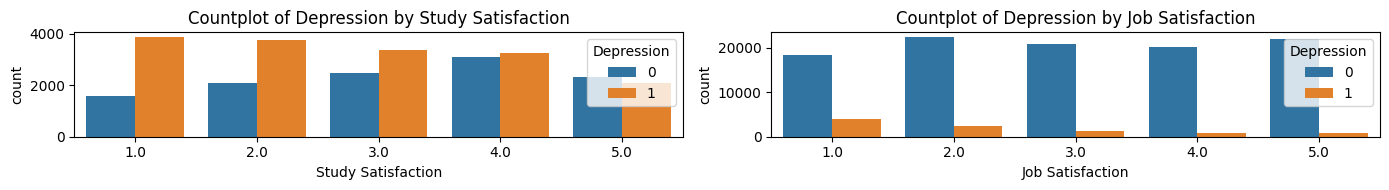

In [27]:
# Countplot of Depression by Study & Job Satisfaction
plt.figure(figsize=(14,2))  
plt.subplot(1, 2, 1) 
sns.countplot(x="Study Satisfaction", hue='Depression', data=train_df)
plt.title("Countplot of Depression by Study Satisfaction")

plt.subplot(1, 2, 2)  
sns.countplot(x="Job Satisfaction", hue='Depression', data=train_df)
plt.title("Countplot of Depression by Job Satisfaction")

plt.tight_layout() 
plt.show()

### 3.10 Sleep Duration

In [28]:
# Sleep Duration class, count & ratio
class_count_ratio(train_df, 'Sleep Duration')[:3]

,Sleep Duration,count,ratio
0,Less than 5 hours,38784,0.275650
1,7-8 hours,36969,0.262751
2,More than 8 hours,32726,0.232594


In [29]:
# select Sleep Duration
sleep_df = pd.DataFrame()
sleep_df = train_df[(train_df['Sleep Duration'] == 'Less than 5 hours') | (
    train_df['Sleep Duration'] == '5-6 hours') | (
    train_df['Sleep Duration'] == '7-8 hours') | (
    train_df['Sleep Duration'] == 'More than 8 hours')].reset_index(drop=True)

print(sleep_df.shape)
sleep_df[:1]

(140621, 20)


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0


In [30]:
# Depression by selected Sleep Duration analysis
depression_by_sleep_duration_filt = depression_by_object_analysis(sleep_df, 'Sleep Duration', 'Depression')
depression_by_sleep_duration_filt
# Men have slightly higher rates of depression than women.

,Sleep Duration,count,depression_count,depression_ratio
0,Less than 5 hours,38784,9101,0.234659
1,7-8 hours,36969,6593,0.178339
2,More than 8 hours,32726,4539,0.138697
3,5-6 hours,32142,5322,0.165578


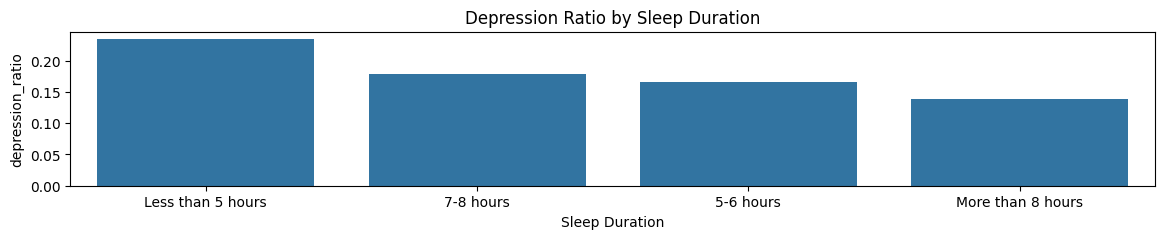

In [31]:
# Depression Ratio by Sleep Duration_filt 
depression_by_sleep_duration_filt = depression_by_sleep_duration_filt.sort_values(by='depression_ratio', 
                                                                        ascending=False)

plt.figure(figsize=(14, 2))
sns.barplot(x="Sleep Duration", y="depression_ratio",data=depression_by_sleep_duration_filt)
            #order=depression_1_by_Sleep_Duration['Sleep Duration']
plt.title("Depression Ratio by Sleep Duration")
plt.show()
# Getting enough sleep can help reduce depression.

### 3.11 Depression by Dietary Habits

In [32]:
# Dietary Habits class, count & ratio
class_count_ratio(train_df, 'Dietary Habits')[:3]

,Dietary Habits,count,ratio
0,Moderate,49705,0.353279
1,Unhealthy,46227,0.328559
2,Healthy,44741,0.317998


In [33]:
# select main Dietary_Habits data 
Dietary_Habits_filt = pd.DataFrame()
Dietary_Habits_filt = train_df[(train_df['Dietary Habits'] == 'Moderate') | (
    train_df['Dietary Habits'] == 'Unhealthy') | (
    train_df['Dietary Habits'] == 'Healthy')].reset_index(drop=True)

print(Dietary_Habits_filt.shape)
Dietary_Habits_filt[:1]

(140673, 20)


,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49,Ludhiana,Working Professional,Chef,NaN,5.0,NaN,NaN,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0


In [34]:
# depression by Dietary Habits_filt analysis
depression_by_object_analysis_filt = depression_by_object_analysis(Dietary_Habits_filt, 'Dietary Habits', 'Depression')
depression_by_object_analysis_filt.sort_values(by='depression_ratio', ascending=False)

,Dietary Habits,count,depression_count,depression_ratio
1,Unhealthy,46227,12044,0.260540
0,Moderate,49705,8233,0.165637
2,Healthy,44741,5281,0.118035


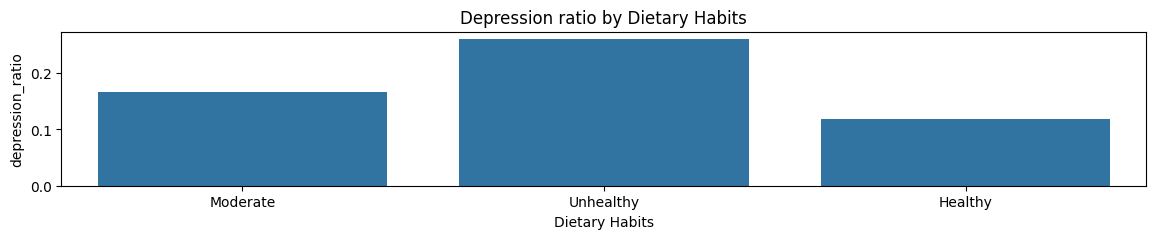

In [35]:
# Countplot of Depression by Dietary Habits_filt
plt.figure(figsize=(14, 2))
sns.barplot(x="Dietary Habits", y="depression_ratio", data=depression_by_object_analysis_filt)
plt.title("Depression ratio by Dietary Habits")
plt.show()

### 3.12 Degree

In [36]:
# Degree class, count & ratio
depression_by_degree = class_count_ratio(train_df, 'Degree')
print(depression_by_degree.shape)
depression_by_degree[:5]
# total len of case 115, 27 classes have enough cases

(115, 3)


,Degree,count,ratio
0,Class 12,14729,0.104685
1,B.Ed,11691,0.083093
2,B.Arch,8742,0.062133
3,B.Com,8113,0.057663
4,B.Pharm,5856,0.041621


In [37]:
# select Degree with enough Depression data and analysis
depression_by_degree = depression_by_object_analysis(train_df, 'Degree', 'Depression')
depression_by_degree_filt  = depression_by_degree[depression_by_degree['count'] >= 6].reset_index(drop=True)
print(depression_by_degree_filt.shape)
depression_by_degree_filt[:1]

(27, 4)


,Degree,count,depression_count,depression_ratio
0,Class 12,14729,7549,0.512526


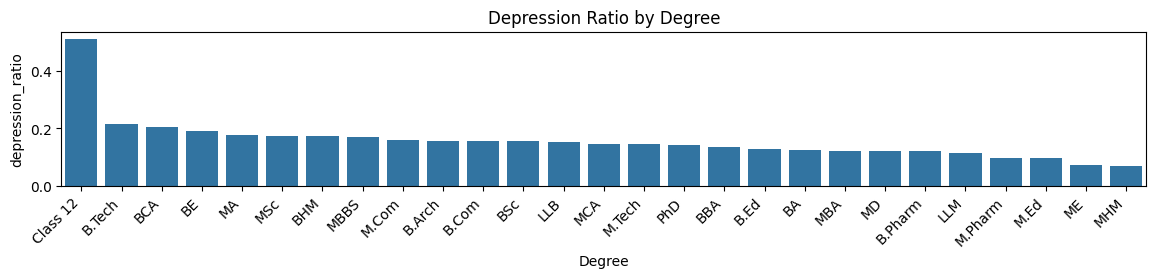

In [38]:
# Depression Ratio by Degree
depression_by_degree_filt = depression_by_degree_filt.sort_values(
    by='depression_ratio', ascending=False)

plt.figure(figsize=(14, 2))
sns.barplot(x="Degree", y="depression_ratio",data=depression_by_degree_filt)
plt.title("Depression Ratio by Degree")
plt.xticks(rotation=45, ha='right')
plt.show()


### 3.13 Depression Ratio by Have you ever had suicidal thoughts?

In [39]:
# depression by "Have you ever had suicidal thoughts ?"
depression_by_object_analysis(train_df, 'Have you ever had suicidal thoughts ?', 'Depression')

,Have you ever had suicidal thoughts ?,count,depression_count,depression_ratio
0,No,71138,3458,0.048610
1,Yes,69562,22109,0.317832


### 3.14 Depression by Work/Study Hours

In [40]:
# depression by work/study hours analysis
depression_by_work_study_hours = depression_by_object_analysis(train_df, 'Work/Study Hours', 'Depression')
depression_by_work_study_hours.sort_values(by='Work/Study Hours', ascending=False)[:5]
# too much Work/Study Hours increase depression ratio

,Work/Study Hours,count,depression_count,depression_ratio
4,12.0,11409,3479,0.304935
1,11.0,12832,3163,0.246493
0,10.0,14199,4556,0.320868
2,9.0,12711,2060,0.162064
12,8.0,8906,2217,0.248933


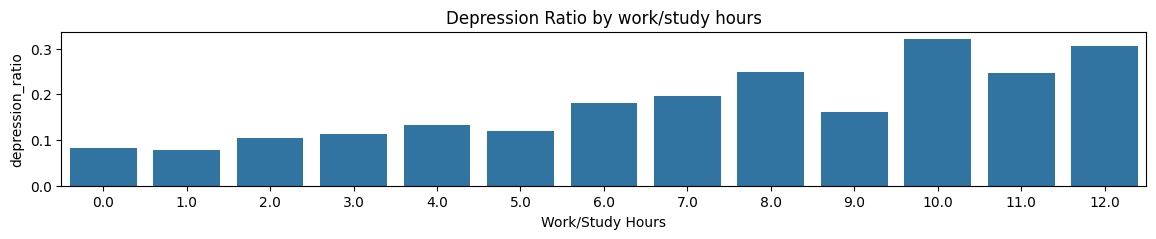

In [41]:
# Depression Ratio by Degree
#work_study_hours_by_depression = degree_by_depression_filt.sort_values(by='depression_ratio', ascending=False)
plt.figure(figsize=(14, 2))
sns.barplot(x="Work/Study Hours", y="depression_ratio",data=depression_by_work_study_hours)
plt.title("Depression Ratio by work/study hours")
plt.show()

### 3.15 Depression by Financial Stress

In [42]:
# depression_by_Financial_Stress
depression_by_Financial_Stress = depression_by_object_analysis(train_df, 'Financial Stress', 'Depression')
depression_by_Financial_Stress.sort_values(by='Financial Stress', ascending=False)[:5]
# Financial Stress increase depression ratio

,Financial Stress,count,depression_count,depression_ratio
1,5.0,28279,9423,0.333215
2,4.0,27765,6114,0.220205
4,3.0,25990,4527,0.174182
0,2.0,31451,3190,0.101428
3,1.0,27211,2312,0.084966


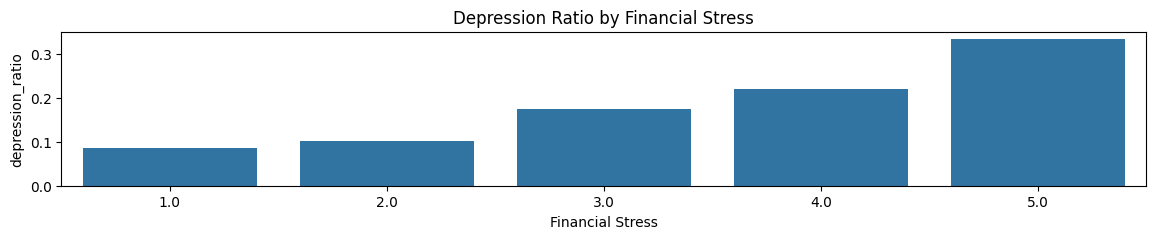

In [43]:
# Depression Ratio by Financial Stress
plt.figure(figsize=(14, 2))
sns.barplot(x="Financial Stress", y="depression_ratio",data=depression_by_Financial_Stress)
plt.title("Depression Ratio by Financial Stress")
plt.show()

### 3.16 Depression by Family History of Mental Illness

In [44]:
# depression_by_Family_Mental_Illness_History
depression_by_Family_Mental_Illness_History = depression_by_object_analysis(
    train_df, 'Family History of Mental Illness', 'Depression')
depression_by_Family_Mental_Illness_History
# Financial Stress increase depression ratio

,Family History of Mental Illness,count,depression_count,depression_ratio
0,No,70758,12410,0.175387
1,Yes,69942,13157,0.188113


### 3.17 Correlation Matrix

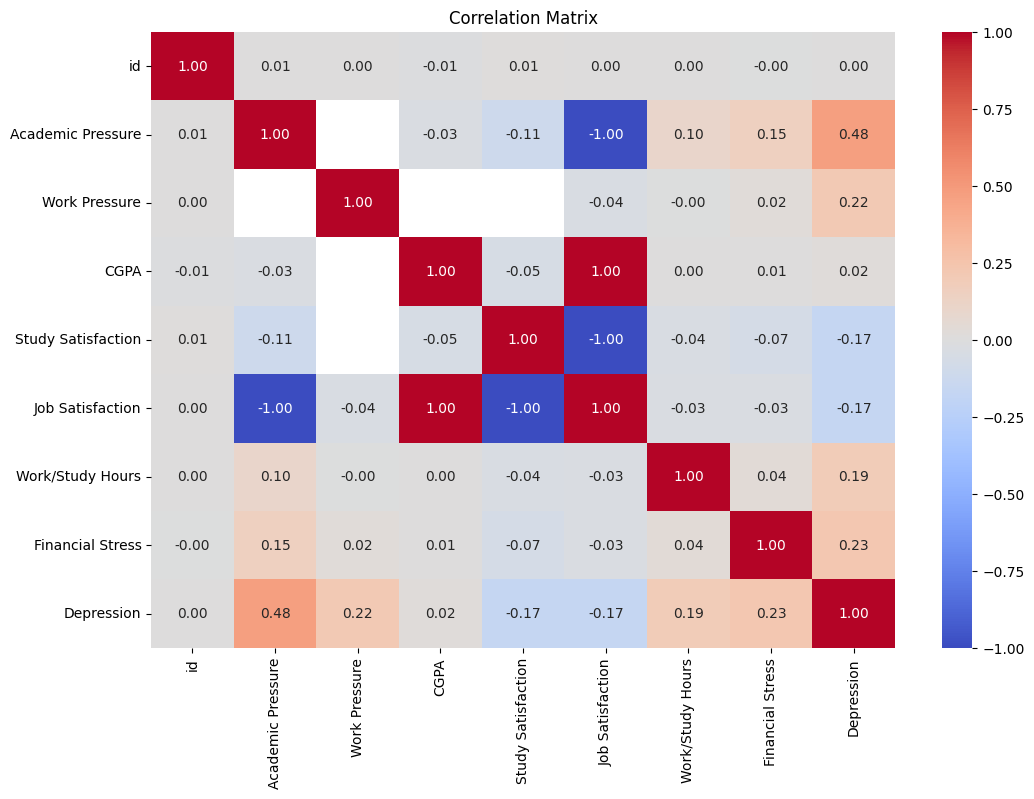

In [45]:
# Select only numerical columns
numerical_df = train_df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
correlation_matrix = numerical_df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix')
plt.show()

#### **1. Korelasi antara Fitur dengan Target (`Depression`):**
- **Academic Pressure** memiliki korelasi **positif sedang** terhadap `Depression` (**0.48**):
  - Semakin tinggi tekanan akademik, semakin besar kemungkinan seseorang mengalami depresi.
- **Financial Stress** memiliki korelasi **positif lemah** terhadap `Depression` (**0.23**):
  - Stres keuangan juga berkontribusi pada depresi, meskipun dampaknya lebih kecil dibandingkan tekanan akademik.
- **Work Pressure** dan **Job Satisfaction** memiliki korelasi **positif lemah** terhadap `Depression` (**0.22 dan 0.19**).
- **Work/Study Hours** dan **Study Satisfaction** menunjukkan korelasi **negatif lemah** terhadap `Depression` (**-0.17** masing-masing):
  - Kepuasan belajar atau waktu kerja/studi yang lebih tinggi mungkin sedikit mengurangi kemungkinan depresi.

---

#### **2. Korelasi Antar-Fitur:**
- **Academic Pressure** memiliki korelasi **negatif kuat** dengan **Job Satisfaction** (**-1.00**):
  - Tekanan akademik yang tinggi cenderung menurunkan kepuasan kerja.
- Korelasi antar fitur lainnya cukup lemah, sehingga tidak banyak masalah multikolinearitas yang terlihat.

---

### **Kesimpulan Utama:**
1. **Fitur Penting**:
   - **Academic Pressure** dan **Financial Stress** adalah kandidat fitur penting untuk prediksi depresi karena memiliki korelasi positif yang signifikan terhadap `Depression`.
2. **Hubungan Antar-Fitur**:
   - Korelasi yang kuat antara **Academic Pressure** dan **Job Satisfaction** (**-1.00**) mengindikasikan hubungan langsung yang penting untuk dianalisis lebih lanjut.

## 4. Data Preparation

In [46]:
# feature, target, test(_feature) data
feature = train_df.drop(['id', 'Name', 'Depression'], axis=1)
target = train_df[['Depression']]
test = test_df.drop(['id', 'Name'], axis=1)

feature.shape, target.shape, test.shape

((140700, 17), (140700, 1), (93800, 17))

In [47]:
missing_values = train_df.isnull().sum()
print(missing_values) 

id                                            0
Name                                          0
Gender                                        0
Age                                           0
City                                          0
Working Professional or Student               0
Profession                                36630
Academic Pressure                        112803
Work Pressure                             27918
CGPA                                     112802
Study Satisfaction                       112803
Job Satisfaction                          27910
Sleep Duration                                0
Dietary Habits                                4
Degree                                        2
Have you ever had suicidal thoughts ?         0
Work/Study Hours                              0
Financial Stress                              4
Family History of Mental Illness              0
Depression                                    0
dtype: int64


### 4.1 Handling Numerical Data

In [48]:
# numeric variables in feature data
feature_num = feature.select_dtypes(include=['int', 'float']).columns
feature_num = feature[feature_num]

test_num = test.select_dtypes(include=['int', 'float']).columns
test_num = test[test_num]

feature_num.shape, test_num.shape

((140700, 8), (93800, 8))

In [49]:
# count of NaN values 
feature_num.isna().sum().sum(), test_num.isna().sum().sum()

(394240, 262652)

In [50]:
# imputation for NaN
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
imputer = SimpleImputer(strategy='median') # 'mean', 'most_frequent'
feature_num_imputed = imputer.fit_transform(feature_num)
test_num_imputed = imputer.transform(test_num)
feature_num_imputed = pd.DataFrame(feature_num_imputed, columns=feature_num.columns)
test_num_imputed = pd.DataFrame(test_num_imputed, columns=test_num.columns)
feature_num_imputed.shape, test_num_imputed.shape

((140700, 8), (93800, 8))

In [51]:
feature_num_imputed.isna().sum().sum()

0

In [52]:
feature_num_imputed.head()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
0,49.0,3.0,5.0,7.77,3.0,2.0,1.0,2.0
1,26.0,3.0,4.0,7.77,3.0,3.0,7.0,3.0
2,33.0,5.0,3.0,8.97,2.0,3.0,3.0,1.0
3,22.0,3.0,5.0,7.77,3.0,1.0,10.0,1.0
4,30.0,3.0,1.0,7.77,3.0,1.0,9.0,4.0


### 4.2 Standardization

In [53]:
feature_num_imputed.columns

Index(['Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
       'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours',
       'Financial Stress'],
      dtype='object')

In [54]:
# Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(feature_num_imputed[feature_num_imputed.columns])

feature_num_st = scaler.transform(feature_num_imputed[feature_num_imputed.columns])
feature_num_st = pd.DataFrame(feature_num_st, columns = feature_num_imputed.columns)

test_num_st = scaler.transform(test_num_imputed[test_num_imputed.columns])
test_num_st = pd.DataFrame(test_num_st, columns = test_num_imputed.columns)

print(feature_num_st.shape, test_num_st.shape)
feature_num_st.head()

(140700, 8) (93800, 8)


,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
0,0.695360,-0.045698,1.589714,0.033784,0.018013,-0.772518,-1.363057,-0.699617
1,-1.161867,-0.045698,0.795176,0.033784,0.018013,0.016183,0.193928,0.007793
2,-0.596624,3.194278,0.000638,1.869755,-1.632006,0.016183,-0.844062,-1.407027
3,-1.484863,-0.045698,1.589714,0.033784,0.018013,-1.561219,0.972421,-1.407027
4,-0.838871,-0.045698,-1.588437,0.033784,0.018013,-1.561219,0.712923,0.715203


### 4.3 Categorical Data

In [55]:
# categoric variables in feature data

feature_cat = feature.select_dtypes(include=['object']).columns
feature_cat = feature[feature_cat]

test_cat = test.select_dtypes(include=['object']).columns
test_cat = test[test_cat]

feature_cat.shape, test_cat.shape

((140700, 9), (93800, 9))

In [56]:
# classes number of object columns
for column in feature_cat.columns:
    print(f"{column} unique value: {feature_cat[column].nunique()}") # feature_cat[column].unique()
# different calsses in categorical columns

Gender unique value: 2
City unique value: 98
Working Professional or Student unique value: 2
Profession unique value: 64
Sleep Duration unique value: 36
Dietary Habits unique value: 23
Degree unique value: 115
Have you ever had suicidal thoughts ? unique value: 2
Family History of Mental Illness unique value: 2


In [57]:
# classes number of object columns
for column in test_cat.columns:
    print(f"{column} unique value: {test_cat[column].nunique()}") # test_cat[column].unique()
# different calsses in categorical columns

Gender unique value: 2
City unique value: 68
Working Professional or Student unique value: 2
Profession unique value: 64
Sleep Duration unique value: 31
Dietary Habits unique value: 22
Degree unique value: 87
Have you ever had suicidal thoughts ? unique value: 2
Family History of Mental Illness unique value: 2


### 4.4 Select Common Classes in Feature and Test

In [58]:
feature_cat.shape, test_cat.shape

((140700, 9), (93800, 9))

In [59]:
feature_cat.isna().sum().sum()

36636

In [60]:
feature_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 9 columns):
 #   Column                                 Non-Null Count   Dtype 
---  ------                                 --------------   ----- 
 0   Gender                                 140700 non-null  object
 1   City                                   140700 non-null  object
 2   Working Professional or Student        140700 non-null  object
 3   Profession                             104070 non-null  object
 4   Sleep Duration                         140700 non-null  object
 5   Dietary Habits                         140696 non-null  object
 6   Degree                                 140698 non-null  object
 7   Have you ever had suicidal thoughts ?  140700 non-null  object
 8   Family History of Mental Illness       140700 non-null  object
dtypes: object(9)
memory usage: 9.7+ MB


In [61]:
# common classes
common_classes_col1 = set(feature_cat['Gender']).intersection(set(test_cat['Gender']))
common_classes_col2 = set(feature_cat['City']).intersection(set(test_cat['City']))
common_classes_col3 = set(feature_cat['Working Professional or Student']).intersection(set(
    test_cat['Working Professional or Student']))
common_classes_col4 = set(feature_cat['Profession']).intersection(set(test_cat['Profession']))
common_classes_col5 = set(feature_cat['Sleep Duration']).intersection(set(test_cat['Sleep Duration']))
common_classes_col6 = set(feature_cat['Dietary Habits']).intersection(set(test_cat['Dietary Habits']))
common_classes_col7 = set(feature_cat['Degree']).intersection(set(test_cat['Degree']))
common_classes_col8 = set(feature_cat['Have you ever had suicidal thoughts ?']).intersection(set(
    test_cat['Have you ever had suicidal thoughts ?']))
common_classes_col9 = set(feature_cat['Family History of Mental Illness']).intersection(set(
    test_cat['Family History of Mental Illness']))

In [62]:
common_classes_col1

{'Female', 'Male'}

In [63]:
# common classes & unknown
def map_to_common_classes(df, column, common_classes):
    return df[column].apply(lambda x: x if x in common_classes else 'unknown')

In [64]:
# new categorical_data with common classes & unknown
feature_cat['Gender'] = map_to_common_classes(feature_cat, 'Gender', common_classes_col1)
test_cat['Gender'] = map_to_common_classes(test_cat, 'Gender', common_classes_col1)

feature_cat['City'] = map_to_common_classes(feature_cat, 'City', common_classes_col2)
test_cat['City'] = map_to_common_classes(test_cat, 'City', common_classes_col2)

feature_cat['Working Professional or Student'] = map_to_common_classes(
    feature_cat, 'Working Professional or Student', common_classes_col3)
test_cat['Working Professional or Student'] = map_to_common_classes(
    test_cat, 'Working Professional or Student', common_classes_col3)

feature_cat['Profession'] = map_to_common_classes(feature_cat, 'Profession', common_classes_col4)
test_cat['Profession'] = map_to_common_classes(test_cat, 'Profession', common_classes_col4)

feature_cat['Sleep Duration'] = map_to_common_classes(feature_cat, 'Sleep Duration', common_classes_col5)
test_cat['Sleep Duration'] = map_to_common_classes(test_cat, 'Sleep Duration', common_classes_col5)

feature_cat['Dietary Habits'] = map_to_common_classes(feature_cat, 'Dietary Habits', common_classes_col6)
test_cat['Dietary Habits'] = map_to_common_classes(test_cat, 'Dietary Habits', common_classes_col6)

feature_cat['Degree'] = map_to_common_classes(feature_cat, 'Degree', common_classes_col7)
test_cat['Degree'] = map_to_common_classes(test_cat, 'Degree', common_classes_col7)

feature_cat['Have you ever had suicidal thoughts ?'] = map_to_common_classes(
    feature_cat, 'Have you ever had suicidal thoughts ?', common_classes_col8)
test_cat['Have you ever had suicidal thoughts ?'] = map_to_common_classes(
    test_cat, 'Have you ever had suicidal thoughts ?', common_classes_col8)

feature_cat['Family History of Mental Illness'] = map_to_common_classes(
    feature_cat, 'Family History of Mental Illness', common_classes_col9)
test_cat['Family History of Mental Illness'] = map_to_common_classes(
    test_cat, 'Family History of Mental Illness', common_classes_col9)

In [65]:
feature_cat.shape

(140700, 9)

In [66]:
# one_hot_encoding 
feature_cat_ohe = pd.get_dummies(feature_cat, columns = feature_cat.columns, 
                                 dtype=int, drop_first=True)
test_cat_ohe = pd.get_dummies(test_cat, columns = test_cat.columns, 
                                 dtype=int, drop_first=True)
print(feature_cat_ohe.shape, test_cat_ohe.shape)
feature_cat_ohe.head(2)

(140700, 169) (93800, 169)


,Gender_Male,City_Ahmedabad,City_Bangalore,City_Bhavna,City_Bhopal,City_Chennai,City_City,City_Delhi,City_Faridabad,City_Ghaziabad,...,Degree_MPharm,Degree_MSc,Degree_Navya,Degree_PhD,Degree_RCA,Degree_S.Pharm,Degree_Vrinda,Degree_unknown,Have you ever had suicidal thoughts ?_Yes,Family History of Mental Illness_Yes
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [67]:
feature_cat.isna().sum().sum(), test_cat.isna().sum().sum()

(36636, 24639)

In [68]:
feature_cat_ohe.isna().sum().sum(), test_cat_ohe.isna().sum().sum()

(0, 0)

In [69]:
feature_tf = pd.concat([feature_num_st, feature_cat_ohe], axis=1)
test_tf = pd.concat([test_num_st, test_cat_ohe], axis=1)
feature_tf.shape, test_tf.shape, target.shape

((140700, 177), (93800, 177), (140700, 1))

In [70]:
# K-fold data splitting
from sklearn.model_selection import KFold
n_folds = 5 

kf = KFold(n_splits=n_folds, shuffle=True, random_state=2411)  

# Empty lists to store training and validation data for each fold
X_train_list, X_val_list, y_train_list, y_val_list = [], [], [], []

# Iterate through each fold
for train_index, val_index in kf.split(feature_tf):
  # Split data into training and validation sets for this fold
  X_train, X_val = feature_tf.iloc[train_index], feature_tf.iloc[val_index]
  y_train, y_val = target.iloc[train_index], target.iloc[val_index]

  # Append the split data for each fold
  X_train_list.append(X_train)
  X_val_list.append(X_val)
  y_train_list.append(y_train)
  y_val_list.append(y_val)

## 5. Modeling

In [71]:
# Define and compile the neural network model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([Dense(units=64, activation='relu', input_dim=177),  
                    Dropout(0.3), 
                    Dense(units=32, activation='relu'),            
                    Dropout(0.2),
                    Dense(units=16, activation='relu'),
                    Dense(units=1, activation='sigmoid')])

model.compile(loss="binary_crossentropy", optimizer = "adam", metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        11,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,017 (54.75 KB)

 Trainable params: 14,017 (54.75 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
best_val_accuracy = 0

# Train the model using KFold Cross-Validation
cv_results = []  
for i in range(n_folds):
  X_train, X_val = X_train_list[i], X_val_list[i]
  y_train, y_val = y_train_list[i], y_val_list[i]

  # Train the model on the current fold
  history = model.fit(X_train, y_train, epochs=10, batch_size=64, 
                      validation_data=(X_val, y_val), verbose=2)
  
  # Get validation accuracy from history
  val_accuracy = history.history['val_accuracy'][-1]

    # Check if this model has the best validation accuracy
  if val_accuracy > best_val_accuracy:
    best_val_accuracy = val_accuracy
    best_model = model  # Save the model with the best performance

  # Append the history object for this fold
  cv_results.append(history)

Epoch 1/10
1759/1759 - 3s - 2ms/step - accuracy: 0.9282 - loss: 0.1797 - val_accuracy: 0.9359 - val_loss: 0.1571
Epoch 2/10
1759/1759 - 2s - 1ms/step - accuracy: 0.9376 - loss: 0.1589 - val_accuracy: 0.9371 - val_loss: 0.1545
Epoch 3/10
1759/1759 - 2s - 967us/step - accuracy: 0.9384 - loss: 0.1560 - val_accuracy: 0.9380 - val_loss: 0.1535
Epoch 4/10
1759/1759 - 2s - 956us/step - accuracy: 0.9393 - loss: 0.1540 - val_accuracy: 0.9375 - val_loss: 0.1539
Epoch 5/10
1759/1759 - 2s - 980us/step - accuracy: 0.9391 - loss: 0.1529 - val_accuracy: 0.9377 - val_loss: 0.1538
Epoch 6/10
1759/1759 - 2s - 951us/step - accuracy: 0.9395 - loss: 0.1519 - val_accuracy: 0.9372 - val_loss: 0.1542
Epoch 7/10
1759/1759 - 2s - 942us/step - accuracy: 0.9402 - loss: 0.1509 - val_accuracy: 0.9378 - val_loss: 0.1544
Epoch 8/10
1759/1759 - 2s - 937us/step - accuracy: 0.9404 - loss: 0.1503 - val_accuracy: 0.9380 - val_loss: 0.1544
Epoch 9/10
1759/1759 - 2s - 959us/step - accuracy: 0.9410 - loss: 0.1490 - val_accur

In [73]:
# accuracy results
print("Final training loss:", history.history['loss'][-1])
print("Final validation loss:", history.history['val_loss'][-1])
print("Final training accuracy:", history.history['accuracy'][-1])
print("Final validation accuracy:", history.history['val_accuracy'][-1])

Final training loss: 0.13810715079307556
Final validation loss: 0.1396012306213379
Final training accuracy: 0.9452647566795349
Final validation accuracy: 0.9444562792778015


## 6. Evaluation

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Evaluate the best model on all validation sets
for i in range(n_folds):
    X_val = X_val_list[i]
    y_val = y_val_list[i]

    # Make predictions using the best model
    y_val_pred = (best_model.predict(X_val) > 0.5).astype("int32")

    # Calculate metrics
    acc = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    cm = confusion_matrix(y_val, y_val_pred)

    # Print metrics for this fold
    print(f"Fold {i+1} Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    print("-" * 50)

# Optionally, you can average the metrics over all folds
avg_acc = np.mean([accuracy_score(y_val_list[i], (best_model.predict(X_val_list[i]) > 0.5).astype("int32")) for i in range(n_folds)])
avg_precision = np.mean([precision_score(y_val_list[i], (best_model.predict(X_val_list[i]) > 0.5).astype("int32")) for i in range(n_folds)])
avg_recall = np.mean([recall_score(y_val_list[i], (best_model.predict(X_val_list[i]) > 0.5).astype("int32")) for i in range(n_folds)])
avg_f1 = np.mean([f1_score(y_val_list[i], (best_model.predict(X_val_list[i]) > 0.5).astype("int32")) for i in range(n_folds)])

print("\nAverage Metrics over all folds:")
print(f"Average Accuracy: {avg_acc:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Average Recall: {avg_recall:.4f}")
print(f"Average F1-score: {avg_f1:.4f}")

880/880 ━━━━━━━━━━━━━━━━━━━━ 1s 547us/step
Fold 1 Metrics:
Accuracy: 0.9495
Precision: 0.8514
Recall: 0.8765
F1-score: 0.8638
Confusion Matrix:
[[22214   786]
 [  635  4505]]
--------------------------------------------------
880/880 ━━━━━━━━━━━━━━━━━━━━ 1s 558us/step
Fold 2 Metrics:
Accuracy: 0.9512
Precision: 0.8624
Recall: 0.8682
F1-score: 0.8653
Confusion Matrix:
[[22363   703]
 [  669  4405]]
--------------------------------------------------
880/880 ━━━━━━━━━━━━━━━━━━━━ 0s 518us/step
Fold 3 Metrics:
Accuracy: 0.9487
Precision: 0.8508
Recall: 0.8754
F1-score: 0.8629
Confusion Matrix:
[[22151   797]
 [  647  4545]]
--------------------------------------------------
880/880 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step
Fold 4 Metrics:
Accuracy: 0.9473
Precision: 0.8517
Recall: 0.8582
F1-score: 0.8549
Confusion Matrix:
[[22288   761]
 [  722  4369]]
--------------------------------------------------
880/880 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step
Fold 5 Metrics:
Accuracy: 0.9445
Precision: 0.8392
Re

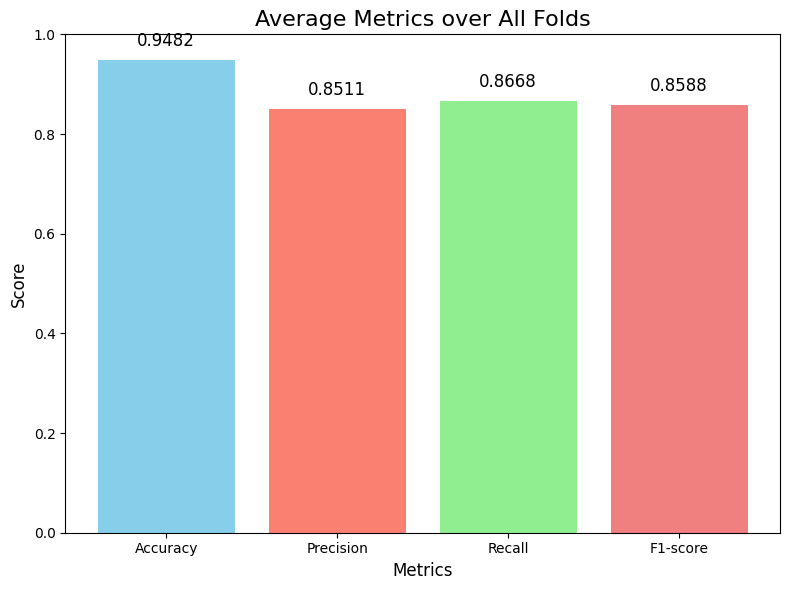

In [75]:
import matplotlib.pyplot as plt

# Average metrics
avg_metrics = [avg_acc, avg_precision, avg_recall, avg_f1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Create a bar plot
plt.figure(figsize=(8, 6))
plt.bar(metrics_names, avg_metrics, color=['skyblue', 'salmon', 'lightgreen', 'lightcoral'])

# Add labels and title
plt.title("Average Metrics over All Folds", fontsize=16)
plt.xlabel("Metrics", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1)

# Display the value on top of each bar
for i, val in enumerate(avg_metrics):
    plt.text(i, val + 0.02, f'{val:.4f}', ha='center', va='bottom', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()


## 7. Save Model For Deployment

In [76]:
import pickle

# Assuming 'model' is your trained model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [77]:
# Assuming 'scaler' is the fitted StandardScaler object
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [78]:
# Save the column names to a file
with open('ohe_columns.pkl', 'wb') as file:
    pickle.dump(feature_cat_ohe.columns.tolist(), file)

In [79]:
# Save the fitted imputer to a .pkl file
with open('imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)